In [ ]:
!pip install datasets -q
!pip install transformers datasets evaluate accelerate -q


In [ ]:
from datasets import load_dataset

dataset = load_dataset("TimSchopf/arxiv_categories")

In [ ]:
# Example mapping to 8 super categories (you can adapt or simplify further)
category_mapping = {
    "cs": "Computer Science",
    "math": "Mathematics",
    "physics": "Physics",
    "astro-ph": "Astrophysics",
    "cond-mat": "Condensed Matter",
    "quant-ph": "Quantum Physics",
    "stat": "Statistics",
    "eess": "Electrical Engineering"
}

def map_label(categories):
    # Just pick the first label and extract its root
    primary = categories[0].split("->")[-1]
    for key in category_mapping:
        if primary.startswith(key):
            return category_mapping[key]
    return "Other"

# Apply mapping
for split in ['train', 'validation', 'test']:
    dataset[split] = dataset[split].map(lambda x: {'label': map_label(x['categories'])})


In [ ]:
!pip install -U sentence-transformers -q

In [ ]:
# Encode titles with MiniLM on GPU
from sentence_transformers import SentenceTransformer
import torch

# Detect device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load model on GPU
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2', device=device)

# Encode titles — set device & batch size for speed
X_train = model.encode(dataset['train']['title'], 
                       batch_size=64, 
                       show_progress_bar=True, 
                       device=device)

X_test = model.encode(dataset['test']['title'], 
                      batch_size=64, 
                      show_progress_bar=True, 
                      device=device)

# Convert labels to numbers
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train = le.fit_transform(dataset['train']['label'])
y_test = le.transform(dataset['test']['label'])


In [ ]:
# ✅ CHOOSE YOUR CLASSIFIER
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import SGDClassifier

# Option 1: Logistic Regression (fast & strong)
clf = LogisticRegression(class_weight='balanced', max_iter=2000, solver='saga', random_state=42, n_jobs=-1)

# Option 2: Random Forest (slow, strong)
#clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)

# Option 3: MLPClassifier (what you had)
# clf = MLPClassifier(hidden_layer_sizes=(128,), max_iter=1000, early_stopping=True, random_state=42)

#Option 4:SGDClassifier
#clf = SGDClassifier(loss='log_loss', class_weight='balanced', max_iter=1000, random_state=42)


# 🧠 Train
clf.fit(X_train, y_train)

In [ ]:
# 📊 Evaluate
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
# F1 scores
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')
print(f"✅ Accuracy: {acc:.4f}")
print(f"🎯 F1 Score (Macro): {f1_macro:.4f}")
print(f"🎯 F1 Score (Weighted): {f1_weighted:.4f}\n")

print("🧾 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))
# 🔲 Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(xticks_rotation=45, cmap="viridis")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# 📉 Class imbalance (Train)
import seaborn as sns
import pandas as pd

label_counts = pd.Series(dataset['train']['label']).value_counts()
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.xticks(rotation=45)
plt.title("Label Distribution (Train)")
plt.ylabel("Count")
plt.show()

🔧 What You Should Do Next
✅ Step 1: Fine-tune DistilBERT on Your Data
Use Hugging Face Transformers.

Tokenize paper titles (or abstracts if available).

Use DistilBertForSequenceClassification.

📦 Libraries needed:

In [ ]:
pip install transformers datasets evaluate accelerate -q


In [1]:
!pip install -U transformers datasets evaluate --quiet


In [ ]:
import transformers
print(transformers.__version__)  # Should be >= 4.0.0


In [2]:
# ✅ Imports
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import load_dataset
import evaluate
import numpy as np
import torch

2025-07-09 12:02:43.422588: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752062563.448848    3777 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752062563.456897    3777 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


debug

In [3]:
# ✅ Load dataset
dataset = load_dataset("TimSchopf/arxiv_categories", trust_remote_code=True)

print("=== DATASET INFO ===")
print(f"Train: {len(dataset['train'])}, Test: {len(dataset['test'])}")

# ✅ FIXED CATEGORY MAPPING for the actual dataset format
def extract_category_prefix(category_string):
    """Extract the actual category from the format 'Archive Name->category'"""
    if '->' in category_string:
        # Split by '->' and get the last part, then split by '.' and get first part
        category_part = category_string.split('->')[-1]
        # Handle cases like 'astro-ph->astro-ph.EP' where we need the middle part
        if '.' in category_part:
            return category_part.split('.')[0]
        else:
            return category_part
    else:
        # Fallback: split by '.' and get first part
        return category_string.split('.')[0]

# Test the extraction on sample data
print("\n=== TESTING CATEGORY EXTRACTION ===")
test_categories = [
    'Computer Science Archive->cs.CV',
    'Mathematics Archive->math.PR', 
    'Physics Archive->astro-ph->astro-ph.EP',
    'Physics Archive->nlin->nlin.CD'
]

for cat in test_categories:
    extracted = extract_category_prefix(cat)
    print(f"'{cat}' -> '{extracted}'")

# ✅ Get all unique category prefixes from the dataset
print("\n=== EXTRACTING ALL CATEGORY PREFIXES ===")
all_prefixes = set()

for sample in dataset['train']:
    categories = sample['categories']
    if isinstance(categories, list):
        for cat in categories:
            if isinstance(cat, str):
                prefix = extract_category_prefix(cat)
                all_prefixes.add(prefix)

print(f"All unique prefixes found: {sorted(all_prefixes)}")

# ✅ Create comprehensive category map
comprehensive_category_map = {}
for i, prefix in enumerate(sorted(all_prefixes)):
    comprehensive_category_map[prefix] = i

print(f"\nComprehensive category map:")
print(f"comprehensive_category_map = {comprehensive_category_map}")

# ✅ FIXED MAPPING FUNCTION
def map_category_fixed(example):
    """Fixed category mapping function"""
    categories = example["categories"]
    
    if isinstance(categories, list):
        for cat in categories:
            if isinstance(cat, str):
                prefix = extract_category_prefix(cat)
                if prefix in comprehensive_category_map:
                    return {"label": comprehensive_category_map[prefix]}
    elif isinstance(categories, str):
        prefix = extract_category_prefix(categories)
        if prefix in comprehensive_category_map:
            return {"label": comprehensive_category_map[prefix]}
    
    return {"label": -1}  # should not happen with comprehensive map

# ✅ Apply the fixed mapping
print("\n=== APPLYING FIXED MAPPING ===")
dataset_mapped = dataset.map(map_category_fixed)

# Count results
train_labels = [ex['label'] for ex in dataset_mapped['train']]
test_labels = [ex['label'] for ex in dataset_mapped['test']]

from collections import Counter
train_label_counts = Counter(train_labels)
test_label_counts = Counter(test_labels)

print(f"TRAIN set results:")
unknown_train = train_label_counts.get(-1, 0)
valid_train = len(train_labels) - unknown_train
print(f"  Valid samples: {valid_train}")
print(f"  Unknown samples: {unknown_train}")

print(f"\nTEST set results:")
unknown_test = test_label_counts.get(-1, 0)
valid_test = len(test_labels) - unknown_test
print(f"  Valid samples: {valid_test}")
print(f"  Unknown samples: {unknown_test}")

# ✅ Filter out unknown samples
dataset_filtered = dataset_mapped.filter(lambda example: example["label"] != -1)

print(f"\n=== AFTER FILTERING ===")
print(f"Train: {len(dataset_filtered['train'])} samples")
print(f"Test: {len(dataset_filtered['test'])} samples")

# ✅ Show label distribution
train_labels_final = [ex['label'] for ex in dataset_filtered['train']]
final_label_counts = Counter(train_labels_final)

print(f"\nFinal label distribution:")
for label, count in sorted(final_label_counts.items()):
    prefix = [k for k, v in comprehensive_category_map.items() if v == label][0]
    print(f"  {prefix} ({label}): {count}")

# ✅ CREATE TRAIN/VALIDATION/TEST SPLITS
print(f"\n=== CREATING SPLITS ===")
# Split test set into validation and test
test_valid_split = dataset_filtered['test'].train_test_split(test_size=0.5, seed=42)

final_dataset = {
    'train': dataset_filtered['train'],
    'validation': test_valid_split['train'],
    'test': test_valid_split['test']
}

print(f"Final splits:")
print(f"Train: {len(final_dataset['train'])}")
print(f"Validation: {len(final_dataset['validation'])}")
print(f"Test: {len(final_dataset['test'])}")

# ✅ TOKENIZATION
print(f"\n=== TOKENIZATION ===")
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(examples):
    texts = []
    for i in range(len(examples['title'])):
        title = examples['title'][i] if examples['title'][i] else ""
        abstract = examples['abstract'][i] if examples['abstract'][i] else ""
        combined_text = f"{title} {abstract}".strip()
        texts.append(combined_text)
    
    return tokenizer(
        texts,
        truncation=True,
        padding=True,
        max_length=256,
        return_tensors=None
    )

# Apply tokenization
tokenized_dataset = {}
for split_name in ['train', 'validation', 'test']:
    print(f"Tokenizing {split_name} set...")
    tokenized_dataset[split_name] = final_dataset[split_name].map(
        tokenize_function,
        batched=True,
        remove_columns=['id', 'title', 'abstract', 'categories', 'creation_date']
    )

print(f"\n=== FINAL RESULTS ===")
for split in ['train', 'validation', 'test']:
    print(f"{split}: {len(tokenized_dataset[split])} samples")

print(f"\n✅ SUCCESS! Dataset is ready for training.")
print(f"Number of categories: {len(comprehensive_category_map)}")
print(f"Category map to use: {comprehensive_category_map}")

=== DATASET INFO ===
Train: 163168, Test: 20397

=== TESTING CATEGORY EXTRACTION ===
'Computer Science Archive->cs.CV' -> 'cs'
'Mathematics Archive->math.PR' -> 'math'
'Physics Archive->astro-ph->astro-ph.EP' -> 'astro-ph'
'Physics Archive->nlin->nlin.CD' -> 'nlin'

=== EXTRACTING ALL CATEGORY PREFIXES ===
All unique prefixes found: ['astro-ph', 'cond-mat', 'cs', 'econ', 'eess', 'gr-qc', 'hep-ex', 'hep-lat', 'hep-ph', 'hep-th', 'math', 'math-ph', 'nlin', 'nucl-ex', 'nucl-th', 'physics', 'q-bio', 'q-fin', 'quant-ph', 'stat']

Comprehensive category map:
comprehensive_category_map = {'astro-ph': 0, 'cond-mat': 1, 'cs': 2, 'econ': 3, 'eess': 4, 'gr-qc': 5, 'hep-ex': 6, 'hep-lat': 7, 'hep-ph': 8, 'hep-th': 9, 'math': 10, 'math-ph': 11, 'nlin': 12, 'nucl-ex': 13, 'nucl-th': 14, 'physics': 15, 'q-bio': 16, 'q-fin': 17, 'quant-ph': 18, 'stat': 19}

=== APPLYING FIXED MAPPING ===
TRAIN set results:
  Valid samples: 163168
  Unknown samples: 0

TEST set results:
  Valid samples: 20397
  Unknown

Map:   0%|          | 0/163168 [00:00<?, ? examples/s]

Tokenizing validation set...


Map:   0%|          | 0/10198 [00:00<?, ? examples/s]

Tokenizing test set...


Map:   0%|          | 0/10199 [00:00<?, ? examples/s]


=== FINAL RESULTS ===
train: 163168 samples
validation: 10198 samples
test: 10199 samples

✅ SUCCESS! Dataset is ready for training.
Number of categories: 20
Category map to use: {'astro-ph': 0, 'cond-mat': 1, 'cs': 2, 'econ': 3, 'eess': 4, 'gr-qc': 5, 'hep-ex': 6, 'hep-lat': 7, 'hep-ph': 8, 'hep-th': 9, 'math': 10, 'math-ph': 11, 'nlin': 12, 'nucl-ex': 13, 'nucl-th': 14, 'physics': 15, 'q-bio': 16, 'q-fin': 17, 'quant-ph': 18, 'stat': 19}


In [4]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [5]:
from transformers import TrainingArguments


In [6]:
num_labels = len(comprehensive_category_map)


from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
)
# Freeze first 3 layers
for i in range(3):
    for param in model.distilbert.transformer.layer[i].parameters():
        param.requires_grad = False


# ✅ Define training arguments
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",                 # ✅ Your original key — perfectly valid
    save_strategy="epoch",                 # Save checkpoints each epoch
    learning_rate=2e-5,
    per_device_train_batch_size=8,         # Smaller batch for GPU fit
    per_device_eval_batch_size=16,
    gradient_accumulation_steps=2,         # Simulates batch size 16
    num_train_epochs=2,                    # Reduce to avoid timeout
    weight_decay=0.01,
    fp16=True,                             # ✅ Mixed precision = faster
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
# ✅ Metric function for Trainer
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    return {"accuracy": acc}

# ✅ Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

/tmp/ipykernel_3777/1093109454.py:9: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [8]:
# ✅ Train
trainer.train()

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy
1,0.482700,0.453906,0.846931
2,0.415600,0.419788,0.856540


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


TrainOutput(global_step=10198, training_loss=0.5036025016442026, metrics={'train_runtime': 4692.7509, 'train_samples_per_second': 69.54, 'train_steps_per_second': 2.173, 'total_flos': 2.162137883541504e+16, 'train_loss': 0.5036025016442026, 'epoch': 2.0})

In [9]:
# ✅ Evaluate
predictions = trainer.predict(tokenized_dataset["test"])
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)
acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc)

/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Accuracy: 0.8551818805765271


ValueError: The number of FixedLocator locations (18), usually from a call to set_ticks, does not match the number of labels (20).

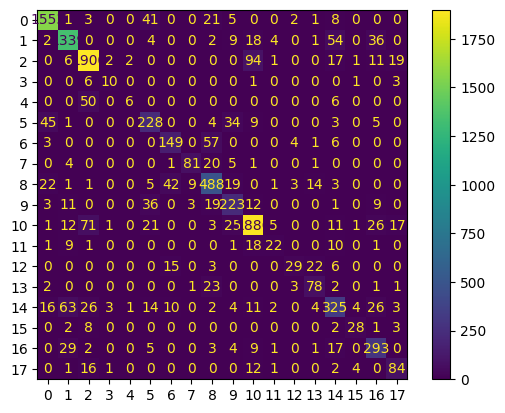

In [10]:
# ✅ Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
labels = [k for k, _ in sorted(comprehensive_category_map.items(), key=lambda x: x[1])]
disp = ConfusionMatrixDisplay(cm, display_labels=labels)
disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

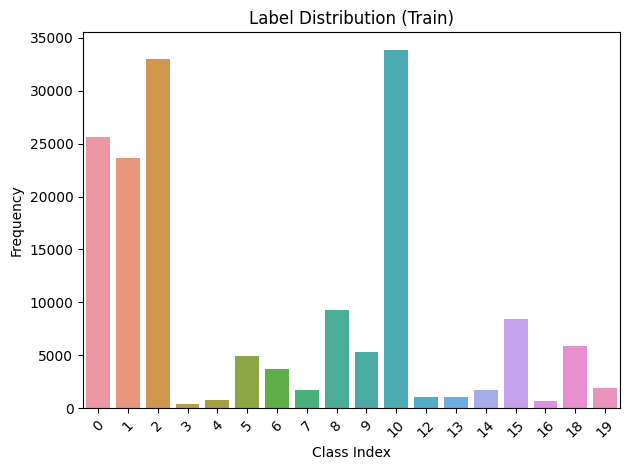

In [11]:
# ✅ Class Distribution (Train Set)
label_counts = pd.Series([ex['label'] for ex in final_dataset['train']])
sns.barplot(x=label_counts.value_counts().index, y=label_counts.value_counts().values)
plt.title("Label Distribution (Train)")
plt.xlabel("Class Index")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


debug

In [ ]:
# Additional imports for evaluation and visualization
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter

# ✅ Setup device and model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [ ]:
# ✅ Model setup
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(comprehensive_category_map)
).to(device)

# ✅ Training arguments
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    evaluation_strategy="steps",
    eval_steps=500,
    save_strategy="steps",
    save_steps=1000,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
)

# ✅ Metrics function
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}

# ✅ Initialize trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)